In [5]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

In [6]:
from data.audio_preprocessor import AudioPreprocessor
from data.speech_commands_ds import SpeechCommandsDataset

In [7]:
data_dir = 'C:/Users/weron/Pulpit/sem1/dl/proj1/Deep-Learning/transformers/dataset/train'

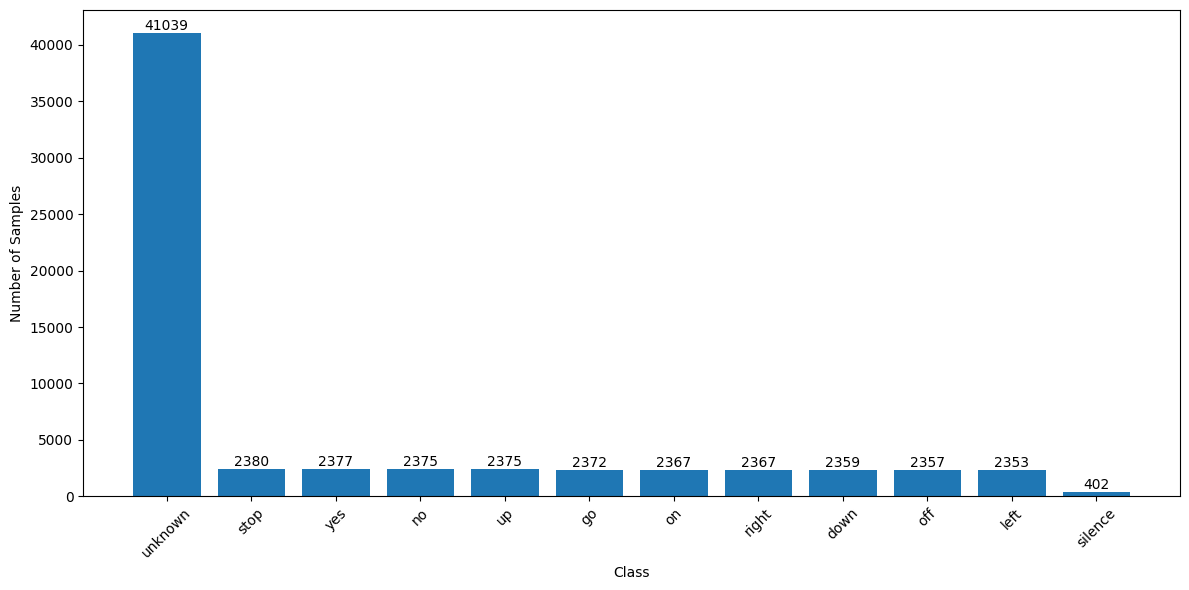

In [12]:
def plot_class_distribution(train_dataset, test_dataset, valid_dataset):
    class_counts = defaultdict(int)
    for _, label in train_dataset.samples:
        class_counts[label] += 1
        
    for _, label in test_dataset.samples:
        class_counts[label] += 1
        
    for _, label in valid_dataset.samples:
        class_counts[label] += 1
    
    sorted_counts = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
    classes, counts = zip(*sorted_counts)
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(classes, counts)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom')
    
    #plt.title(f'Class Distribution: {title}')
    plt.xlabel('Class')
    plt.ylabel('Number of Samples')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

preprocessor = AudioPreprocessor()

train_dataset = SpeechCommandsDataset(
    root_dir=data_dir,
    file_list_path='train_list.txt',
    mode='1d',
    vsu=False,
    preprocessor=preprocessor,
    augment=False
)

valid_dataset = SpeechCommandsDataset(
    root_dir=data_dir,
    file_list_path='validation_list.txt',
    mode='1d',
    vsu=False,
    preprocessor=preprocessor,
    augment=False
)

test_dataset = SpeechCommandsDataset(
    root_dir=data_dir,
    file_list_path='testing_list.txt',
    mode='1d',
    vsu=False,
    preprocessor=preprocessor,
    augment=False
)

plot_class_distribution(train_dataset, test_dataset, valid_dataset)